In [4]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import motifs
from Bio import SeqIO
from Bio.Seq import Seq

In [10]:
def compute_cpg_ratio(window: str):
    """
    считаем частоты и отношение
    """
    length = len(window)
    

    p_C = window.count('C') 
    p_G = window.count('G')
    

    cg_count = sum(1 for i in range(length - 1) if window[i:i+2] == 'CG')
    p_CG = cg_count 
    
    R_CG = p_CG / (p_C * p_G) if p_C * p_G > 0 else 0
    
    # GC%
    GC_percent = 100 * (p_C + p_G) / length
    
    return R_CG, GC_percent


def scan_sequence(sequence: str, window_size: int = 200, step: int = 1):
    positions = []
    R_values = []
    GC_values = []
    
    for i in range(0, len(sequence) - window_size + 1, step):
        window = sequence[i:i+window_size]
        R_CG, GC_percent = compute_cpg_ratio(window)
        positions.append(i + window_size // 2) 
        R_values.append(R_CG)
        GC_values.append(GC_percent)

    return np.array(positions), np.array(R_values), np.array(GC_values)

ID: 1
Description: 1 dna:chromosome chromosome:GRCh38:1:1:248956422:1 REF
Length: 248956422
First 100 bp: NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN


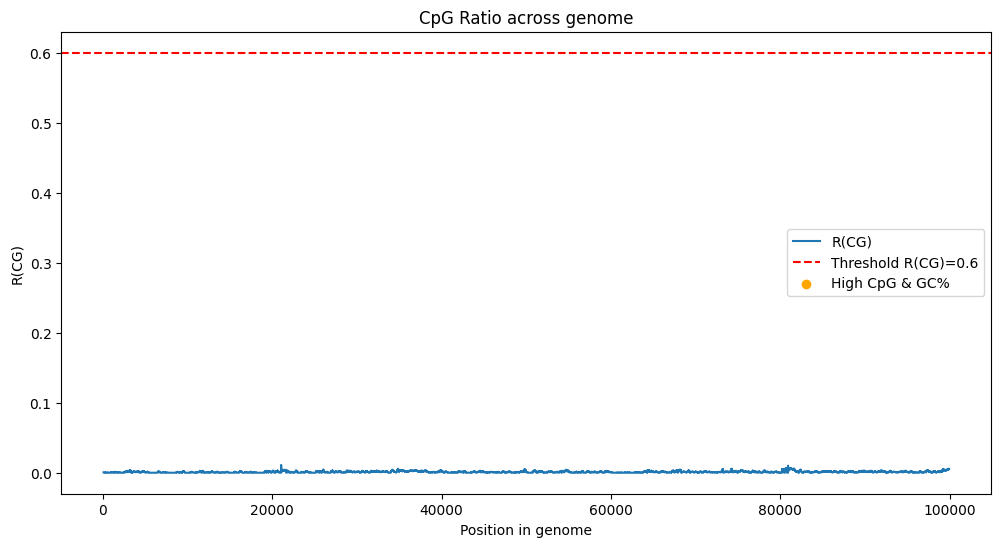

In [11]:
for record in SeqIO.parse("/Users/antonkorotkov/Homo_sapiens.GRCh38.dna.chromosome.1.fa", "fasta"):
    print("ID:", record.id)
    print("Description:", record.description)
    print("Length:", len(record.seq))
    print("First 100 bp:", record.seq[:100])
    

sequence = str(record.seq[100000:200000])
positions, R_values, GC_values = scan_sequence(sequence, window_size=200)


high_cpg = (R_values > 0.6) & (GC_values > 50)

plt.figure(figsize=(12, 6))
plt.plot(positions, R_values, label='R(CG)')
plt.axhline(0.6, color='red', linestyle='--', label='Threshold R(CG)=0.6')
plt.scatter(positions[high_cpg], R_values[high_cpg], color='orange', label='High CpG & GC%')
plt.xlabel('Position in genome')
plt.ylabel('R(CG)')
plt.title('CpG Ratio across genome')
plt.legend()
plt.show()